In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import pandas as pd
%matplotlib inline

# 1. CPU 모드로 모델 로드
def load_model_on_cpu(model_path):
    model = YOLO(model_path)
    model.to('cpu')
    print(f"모델 장치: {model.device}")
    return model

# 2. 단일 이미지 추론
def predict_single_image(model, image_path, conf=0.25, save=True):
    results = model.predict(
        source=image_path,
        conf=conf,
        device='cpu',
        imgsz=320,
        batch=4,
        save=save
    )
    return results

# 3. 결과 시각화
def visualize_result(output_img_path):
    if os.path.exists(output_img_path):
        img_result = cv2.imread(output_img_path)
        img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 8))
        plt.imshow(img_result)
        plt.axis("off")
        plt.title("YOLOv5 Inference on CPU")
        plt.show()
    else:
        print("결과 이미지를 찾을 수 없습니다.")

In [2]:
# 4. 배치 처리 및 결과 수집
def batch_inference(model, image_dir, output_dir, conf=0.25, max_images=50, ground_truth_file=None):
    os.makedirs(output_dir, exist_ok=True)
    image_files = glob.glob(os.path.join(image_dir, "*.jpg"))
    
    # 처리할 이미지 수 제한
    if len(image_files) > max_images:
        print(f"총 {len(image_files)}개 이미지 중 처음 {max_images}개만 처리합니다.")
        image_files = image_files[:max_images]
    else:
        print(f"총 {len(image_files)}개의 이미지를 처리합니다.")
    
    all_results = []
    all_gt = []
    
    # 클래스 이름 가져오기
    class_names = model.names
    
    # ground truth 로드 (VOC 형식 가정)
    if ground_truth_file:
        gt_data = load_ground_truth(ground_truth_file, class_names)
    
    for img_path in tqdm(image_files, desc="추론 진행"):
        img_name = Path(img_path).stem
        
        results = model.predict(
            source=img_path,
            conf=conf,
            device='cpu',
            imgsz=320,
            batch=1,
            save=True,
            project=output_dir,
            name=img_name
        )
        
        # 결과 수집
        if len(results) > 0:
            boxes = results[0].boxes
            img_results = []
            
            if boxes.shape[0] > 0:
                for box in boxes:
                    cls_id = int(box.cls.item())
                    confidence = box.conf.item()
                    img_results.append({
                        'image': img_name,
                        'class_id': cls_id, 
                        'class_name': class_names[cls_id],
                        'confidence': confidence,
                        'bbox': box.xyxy[0].tolist()
                    })
            
            all_results.extend(img_results)
            
            # ground truth 데이터 추가
            if ground_truth_file and img_name in gt_data:
                all_gt.extend(gt_data[img_name])
        
        # 메모리 해제
        del results
    
    return all_results, all_gt, class_names

# 5. Ground Truth 로드 (VOC 형식 가정)
def load_ground_truth(annotation_dir, class_names):
    gt_data = {}
    annotation_files = glob.glob(os.path.join(annotation_dir, "*.xml"))
    
    print(f"어노테이션 파일 {len(annotation_files)}개를 찾았습니다.")
    if len(annotation_files) == 0:
        print(f"경고: {annotation_dir} 경로에 XML 파일이 없습니다!")
        return gt_data
    
    import xml.etree.ElementTree as ET
    
    for xml_file in annotation_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            filename_elem = root.find('filename')
            if filename_elem is None:
                print(f"경고: {xml_file}에 filename 요소가 없습니다.")
                continue
                
            img_name = filename_elem.text.split('.')[0]
            gt_data[img_name] = []
            
            for obj in root.findall('object'):
                name_elem = obj.find('name')
                if name_elem is None:
                    continue
                    
                class_name = name_elem.text
                
                # 클래스 이름을 인덱스로 변환
                class_id = None
                for k, v in class_names.items():
                    if v == class_name:
                        class_id = k
                        break
                
                if class_id is None:
                    # print(f"경고: 클래스 '{class_name}'이 모델의 클래스에 없습니다.")
                    continue
                    
                bbox = obj.find('bndbox')
                if bbox is None:
                    continue
                    
                xmin_elem = bbox.find('xmin')
                ymin_elem = bbox.find('ymin')
                xmax_elem = bbox.find('xmax')
                ymax_elem = bbox.find('ymax')
                
                if None in (xmin_elem, ymin_elem, xmax_elem, ymax_elem):
                    continue
                    
                xmin = float(xmin_elem.text)
                ymin = float(ymin_elem.text)
                xmax = float(xmax_elem.text)
                ymax = float(ymax_elem.text)
                
                gt_data[img_name].append({
                    'image': img_name,
                    'class_id': class_id,
                    'class_name': class_name,
                    'bbox': [xmin, ymin, xmax, ymax]
                })
                
        except Exception as e:
            print(f"오류: {xml_file} 처리 중 예외 발생: {e}")
            
    print(f"Ground Truth 데이터: 이미지 {len(gt_data)}개를 로드했습니다.")
    return gt_data

In [3]:
# 6. mAP 계산 및 혼동 행렬 생성
def calculate_metrics(all_results, all_gt, class_names, iou_threshold=0.5):
    # 클래스별 TP, FP, FN 초기화
    class_metrics = {cls_id: {'TP': 0, 'FP': 0, 'FN': 0} for cls_id in class_names}
    
    # 예측과 실제값을 이미지별로 그룹화
    results_by_image = {}
    gt_by_image = {}
    
    for result in all_results:
        img_name = result['image']
        if img_name not in results_by_image:
            results_by_image[img_name] = []
        results_by_image[img_name].append(result)
    
    for gt in all_gt:
        img_name = gt['image']
        if img_name not in gt_by_image:
            gt_by_image[img_name] = []
        gt_by_image[img_name].append(gt)
    
    # 혼동 행렬 초기화
    n_classes = len(class_names)
    confusion_mat = np.zeros((n_classes, n_classes))
    
    # 이미지별로 매칭
    for img_name in gt_by_image.keys():
        if img_name not in results_by_image:
            # 이미지에 예측이 없는 경우: 모든 GT를 FN으로 처리
            for gt in gt_by_image[img_name]:
                class_metrics[gt['class_id']]['FN'] += 1
            continue
        
        # 이 이미지의 예측값과 실제값
        img_results = results_by_image[img_name]
        img_gt = gt_by_image[img_name]
        
        # GT 박스별 매칭 여부 추적
        gt_matched = [False] * len(img_gt)
        
        # 신뢰도 기준 내림차순 정렬
        img_results = sorted(img_results, key=lambda x: x['confidence'], reverse=True)
        
        for result in img_results:
            pred_cls = result['class_id']
            pred_bbox = result['bbox']
            
            best_iou = 0
            best_match_idx = -1
            
            # 각 GT 박스와 IoU 계산
            for i, gt in enumerate(img_gt):
                if gt_matched[i]:
                    continue  # 이미 매칭된 GT 박스는 건너뜀
                
                gt_cls = gt['class_id']
                gt_bbox = gt['bbox']
                
                iou = calculate_iou(pred_bbox, gt_bbox)
                
                if iou > best_iou:
                    best_iou = iou
                    best_match_idx = i
            
            # 매칭 결과 처리
            if best_iou >= iou_threshold:
                gt_cls = img_gt[best_match_idx]['class_id']
                
                # TP - 같은 클래스와 매칭된 경우
                if pred_cls == gt_cls:
                    class_metrics[pred_cls]['TP'] += 1
                    confusion_mat[gt_cls, pred_cls] += 1
                else:
                    # 다른 클래스와 매칭됨 (FP for pred_cls, FN for gt_cls)
                    class_metrics[pred_cls]['FP'] += 1
                    class_metrics[gt_cls]['FN'] += 1
                    confusion_mat[gt_cls, pred_cls] += 1
                
                gt_matched[best_match_idx] = True
            else:
                # 매칭 실패 (FP)
                class_metrics[pred_cls]['FP'] += 1
                # 백그라운드 클래스(없는 경우)는 n_classes-1로 설정
                confusion_mat[n_classes-1, pred_cls] += 1
        
        # 매칭되지 않은 GT는 FN
        for i, matched in enumerate(gt_matched):
            if not matched:
                gt_cls = img_gt[i]['class_id']
                class_metrics[gt_cls]['FN'] += 1
                # 누락된 예측은 백그라운드 클래스로 설정
                confusion_mat[gt_cls, n_classes-1] += 1
    
    # 클래스별 precision, recall, F1-score, mAP 계산
    class_scores = {}
    
    for cls_id, metrics in class_metrics.items():
        TP = metrics['TP']
        FP = metrics['FP']
        FN = metrics['FN']
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        class_scores[cls_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'TP': TP,
            'FP': FP,
            'FN': FN
        }
    
    # 행 표준화된 혼동 행렬 계산 (각 GT 클래스당 비율)
    norm_confusion_mat = np.zeros_like(confusion_mat, dtype=float)
    for i in range(confusion_mat.shape[0]):
        row_sum = confusion_mat[i].sum()
        if row_sum > 0:
            norm_confusion_mat[i] = confusion_mat[i] / row_sum
    
    return class_scores, confusion_mat, norm_confusion_mat

# 7. IoU 계산 함수
def calculate_iou(box1, box2):
    # 박스 좌표: [x1, y1, x2, y2]
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # 교집합 영역 계산
    x_left = max(x1_min, x2_min)
    y_top = max(y1_min, y2_min)
    x_right = min(x1_max, x2_max)
    y_bottom = min(y1_max, y2_max)
    
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    
    # 합집합 영역 계산
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    
    union_area = box1_area + box2_area - intersection_area
    
    return intersection_area / union_area

# 8. 가장 낮은 성능의 클래스 시각화
def visualize_worst_class(model, test_dir, output_dir, class_scores, class_names, max_images=5):
    # 성능이 가장 낮은 클래스 찾기 (F1 점수 기준)
    # 클래스 스코어가 비어있는지 확인
    if not class_scores:
        print("클래스 성능 점수가 비어있습니다. Ground Truth 데이터가 있는지 확인하세요.")
        return None, None
        
    worst_class_id = min(class_scores, key=lambda k: class_scores[k]['f1'] if class_scores[k]['f1'] is not None else float('inf'))
    worst_class_name = class_names[worst_class_id]
    worst_class_score = class_scores[worst_class_id]
    
    print(f"\n가장 낮은 성능의 클래스: {worst_class_name} (클래스 ID: {worst_class_id})")
    print(f"정밀도: {worst_class_score['precision']:.4f}, 재현율: {worst_class_score['recall']:.4f}, F1 점수: {worst_class_score['f1']:.4f}")
    print(f"TP: {worst_class_score['TP']}, FP: {worst_class_score['FP']}, FN: {worst_class_score['FN']}")
    
    # 해당 클래스의 이미지 찾기
    image_files = glob.glob(os.path.join(test_dir, "*.jpg"))
    
    worst_class_images = []
    
    # 이미지를 순회하며 해당 클래스를 포함하는 이미지 찾기
    for img_path in tqdm(image_files, desc=f"{worst_class_name} 클래스 이미지 검색"):
        results = model.predict(
            source=img_path,
            conf=0.25,
            device='cpu',
            imgsz=320,
            batch=1,
            save=False
        )
        
        if len(results) > 0:
            boxes = results[0].boxes
            
            if boxes.shape[0] > 0:
                # 클래스별 개수 세기
                detected_classes = boxes.cls.cpu().numpy().astype(int)
                
                # 해당 클래스가 있으면 이미지 저장
                if worst_class_id in detected_classes:
                    worst_class_images.append(img_path)
                    
                    # 충분한 이미지를 찾으면 중단
                    if len(worst_class_images) >= max_images:
                        break
        
        del results
    
    # 발견된 이미지 시각화
    found_images = len(worst_class_images)
    if found_images == 0:
        print(f"{worst_class_name} 클래스에 해당하는 이미지를 찾지 못했습니다.")
        return None
    
    print(f"{worst_class_name} 클래스에 해당하는 이미지 {found_images}개를 찾았습니다.")
    
    # 이미지 시각화 및 문제점 분석
    fig, axes = plt.subplots(1, found_images, figsize=(5*found_images, 5))
    
    if found_images == 1:
        axes = [axes]
    
    for i, img_path in enumerate(worst_class_images):
        # 원본 이미지 로드
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 추론 실행
        results = model.predict(
            source=img_path,
            conf=0.1,  # 낮은 신뢰도로 설정하여 더 많은 예측 확인
            device='cpu',
            imgsz=320,
            batch=1,
            save=False
        )
        
        # 이미지에 경계 상자 그리기
        if len(results) > 0:
            boxes = results[0].boxes
            
            if boxes.shape[0] > 0:
                for box in boxes:
                    cls_id = int(box.cls.item())
                    confidence = box.conf.item()
                    xyxy = box.xyxy[0].cpu().numpy().astype(int)
                    
                    color = (0, 255, 0)  # 녹색 (다른 클래스)
                    if cls_id == worst_class_id:
                        color = (255, 0, 0)  # 빨간색 (대상 클래스)
                    
                    # 경계 상자 그리기
                    cv2.rectangle(img, (xyxy[0], xyxy[1]), (xyxy[2], xyxy[3]), color, 2)
                    
                    # 클래스 이름과 신뢰도 표시
                    label = f"{class_names[cls_id]}: {confidence:.2f}"
                    cv2.putText(img, label, (xyxy[0], xyxy[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        # 이미지 표시
        axes[i].imshow(img)
        axes[i].set_title(f"{worst_class_name} Detection")
        axes[i].axis("off")
        
        del results
    
    plt.tight_layout()
    
    # 시각화 저장
    vis_path = os.path.join(output_dir, f"{worst_class_name}_visualization.png")
    plt.savefig(vis_path)
    plt.show()
    
    # 문제점 분석
    analyze_worst_class_issues(worst_class_id, worst_class_name, worst_class_score, class_scores, found_images)
    
    return worst_class_id, worst_class_name

In [4]:
# 9. 클래스별 문제점 분석
def analyze_worst_class_issues(worst_class_id, worst_class_name, worst_class_score, class_scores, found_images):
    print("\n## 문제점 분석 ##")
    
    # 가능한 문제점 목록
    possible_issues = []
    
    # 문제점 1: 데이터 불균형
    if worst_class_score['TP'] + worst_class_score['FN'] < 10:
        possible_issues.append("데이터 불균형: 해당 클래스의 샘플 수가 매우 적습니다. 데이터셋에 더 많은 샘플을 추가하거나 데이터 증강 기법을 적용하세요.")
    
    # 문제점 2: 낮은 재현율
    if worst_class_score['recall'] < 0.5 and worst_class_score['precision'] > 0.7:
        possible_issues.append("낮은 재현율: 모델이 해당 클래스의 객체를 놓치는 경향이 있습니다. 이는 다양한 환경, 크기, 방향의 샘플이 부족하거나 클래스 불균형 때문일 수 있습니다.")
    
    # 문제점 3: 낮은 정밀도
    if worst_class_score['precision'] < 0.5 and worst_class_score['recall'] > 0.7:
        possible_issues.append("낮은 정밀도: 모델이 다른 객체를 해당 클래스로 잘못 분류하는 경향이 있습니다. 이는 시각적으로 유사한 클래스와의 혼동 때문일 수 있습니다.")
    
    # 문제점 4: 전반적으로 낮은 성능
    if worst_class_score['precision'] < 0.5 and worst_class_score['recall'] < 0.5:
        possible_issues.append("전반적으로 낮은 성능: 모델이 이 클래스를 인식하는 데 큰 어려움을 겪고 있습니다. 더 많은 데이터와 더 깊은 모델 아키텍처가 필요할 수 있습니다.")
    
    # 문제점 5: 발견된 이미지 수 적음
    if found_images < 3:
        possible_issues.append("테스트셋에서 해당 클래스의 이미지가 적게 발견되었습니다. 이는 클래스 불균형이나 해당 클래스의 샘플이 테스트셋에 충분히 포함되지 않았을 가능성을 나타냅니다.")
    
    # 문제점 없음 또는 기본 문제점
    if not possible_issues:
        possible_issues.append("이 클래스는 다른 클래스에 비해 복잡한 특징을 가지고 있거나, 학습 데이터에서 충분히 다양한 사례를 포함하지 않았을 수 있습니다. 해당 클래스의 다양한 변형, 크기, 방향을 포함하는 더 많은 데이터를 수집하세요.")
    
    # 가장 중요한 문제점 출력
    print(f"{worst_class_name} 클래스의 주요 문제점:")
    for i, issue in enumerate(possible_issues, 1):
        print(f"{i}. {issue}")
    
    # 개선 제안
    print("\n개선 제안:")
    print("1. 해당 클래스의 데이터를 더 수집하고 다양한 환경, 각도, 조명 조건에서의 샘플을 확보하세요.")
    print("2. 데이터 증강 기법을 적용하여 데이터셋의 다양성을 높이세요.")
    print("3. 클래스 간 혼동이 심한 경우, 특징 추출을 강화할 수 있는 backbone 네트워크나 앙상블 접근법을 고려하세요.")
    print("4. 테스트셋과 훈련셋 간의 분포 차이를 확인하고, 필요시 훈련 데이터를 조정하세요.")

# 10. 혼동 행렬 시각화
def plot_confusion_matrix(confusion_mat, norm_confusion_mat, class_names, output_dir):
    n_classes = len(class_names)
    
    # 클래스 이름 리스트 생성
    class_list = [class_names[i] for i in range(n_classes)]
    
    # 원본 혼동 행렬 시각화
    plt.figure(figsize=(12, 10))
    sns.heatmap(confusion_mat, annot=True, fmt='.0f', cmap='Blues', 
                xticklabels=class_list, yticklabels=class_list)
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
    plt.show()
    
    # 정규화된 혼동 행렬 시각화
    plt.figure(figsize=(12, 10))
    sns.heatmap(norm_confusion_mat, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=class_list, yticklabels=class_list)
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Normalized Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'normalized_confusion_matrix.png'))
    plt.show()

모델 장치: cpu
배치 추론 및 성능 분석을 시작합니다...
총 5011개 이미지 중 처음 100개만 처리합니다.
어노테이션 파일 5011개를 찾았습니다.
Ground Truth 데이터: 이미지 5011개를 로드했습니다.


추론 진행:   0%|                                                                               | 0/100 [00:00<?, ?it/s]


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000005.jpg: 256x320 5 chairs, 91.8ms
Speed: 0.9ms preprocess, 91.8ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 320)
Results saved to results\cpu_inference_analysis\0000059


추론 진행:   1%|▋                                                                      | 1/100 [00:00<00:57,  1.73it/s]


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000007.jpg: 224x320 1 car, 84.7ms
Speed: 0.7ms preprocess, 84.7ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 320)
Results saved to results\cpu_inference_analysis\0000079


...


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000194.jpg: 224x320 1 horse, 1 person, 71.0ms
Speed: 0.4ms preprocess, 71.0ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 320)
Results saved to results\cpu_inference_analysis\0001949

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000198.jpg: 224x320 1 train, 72.2ms
Speed: 0.6ms preprocess, 72.2ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 320)
Results saved to results\cpu_inference_analysis\0001989


추론 진행:  99%|█████████████████████████████████████████████████████████████████████▎| 99/100 [00:09<00:00, 10.45it/s]


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000200.jpg: 160x320 7 persons, 63.9ms
Speed: 0.8ms preprocess, 63.9ms inference, 0.9ms postprocess per image at shape (1, 3, 160, 320)
Results saved to results\cpu_inference_analysis\0002009


추론 진행: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [00:10<00:00,  9.92it/s]

성능 지표를 계산 중입니다...

클래스별 성능:
클래스 0 (aeroplane): Precision=0.6667, Recall=0.3333, F1=0.4444
클래스 1 (bicycle): Precision=0.9000, Recall=1.0000, F1=0.9474
클래스 2 (bird): Precision=1.0000, Recall=0.8571, F1=0.9231
클래스 3 (boat): Precision=0.4545, Recall=0.5000, F1=0.4762
클래스 4 (bottle): Precision=0.8333, Recall=0.5000, F1=0.6250
클래스 5 (bus): Precision=1.0000, Recall=0.6667, F1=0.8000
클래스 6 (car): Precision=0.9565, Recall=0.7333, F1=0.8302
클래스 7 (cat): Precision=0.7500, Recall=0.6667, F1=0.7059
클래스 8 (chair): Precision=0.5000, Recall=0.3182, F1=0.3889
클래스 9 (cow): Precision=0.0000, Recall=0.0000, F1=0.0000
클래스 10 (diningtable): Precision=0.5000, Recall=0.5000, F1=0.5000
클래스 11 (dog): Precision=0.6154, Recall=0.7273, F1=0.6667
클래스 12 (horse): Precision=0.8571, Recall=0.8571, F1=0.8571
클래스 13 (motorbike): Precision=1.0000, Recall=0.8333, F1=0.9091
클래스 14 (person): Precision=0.7658, Recall=0.7798, F1=0.7727
클래스 15 (pottedplant): Precision=0.4286, Recall=0.3750, F1=0.4000
클래스 16 (sheep): Precision=

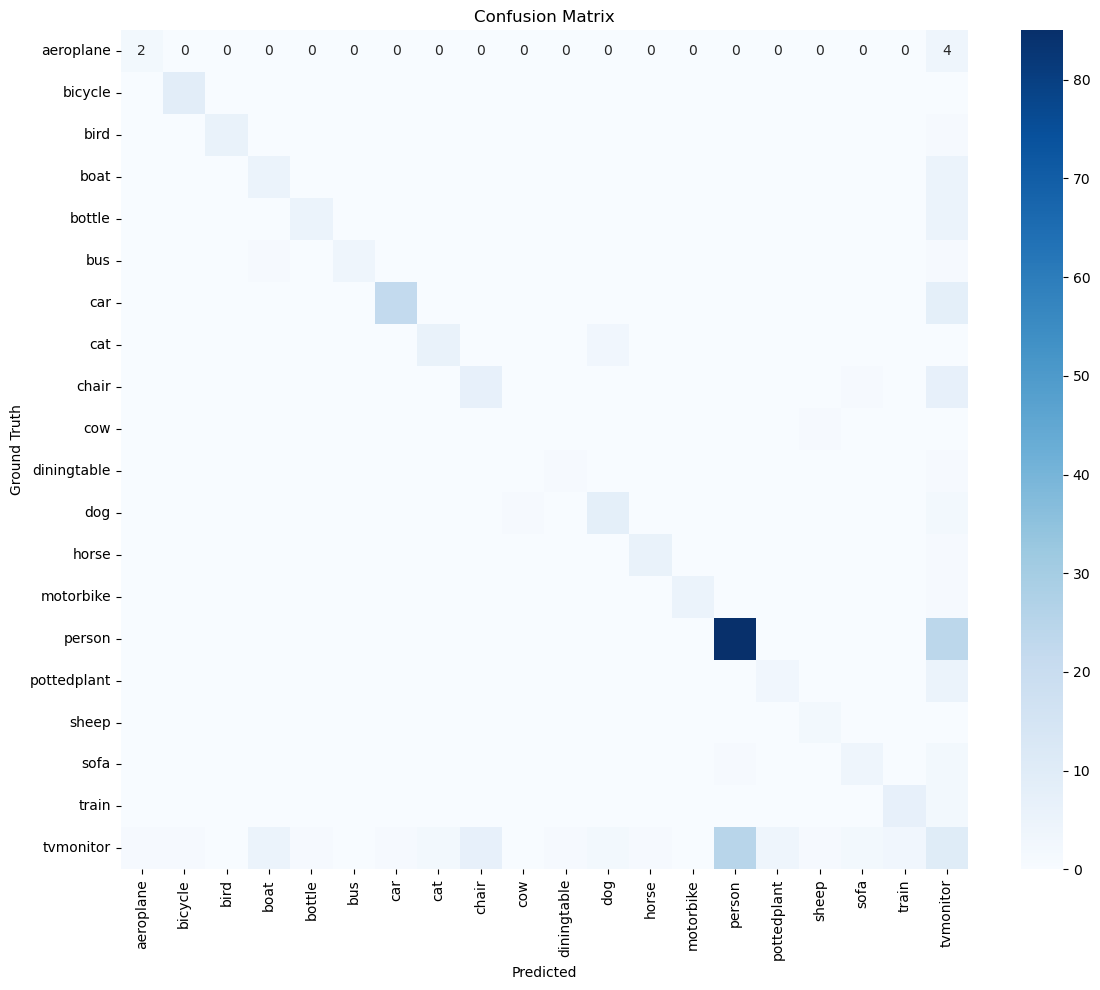

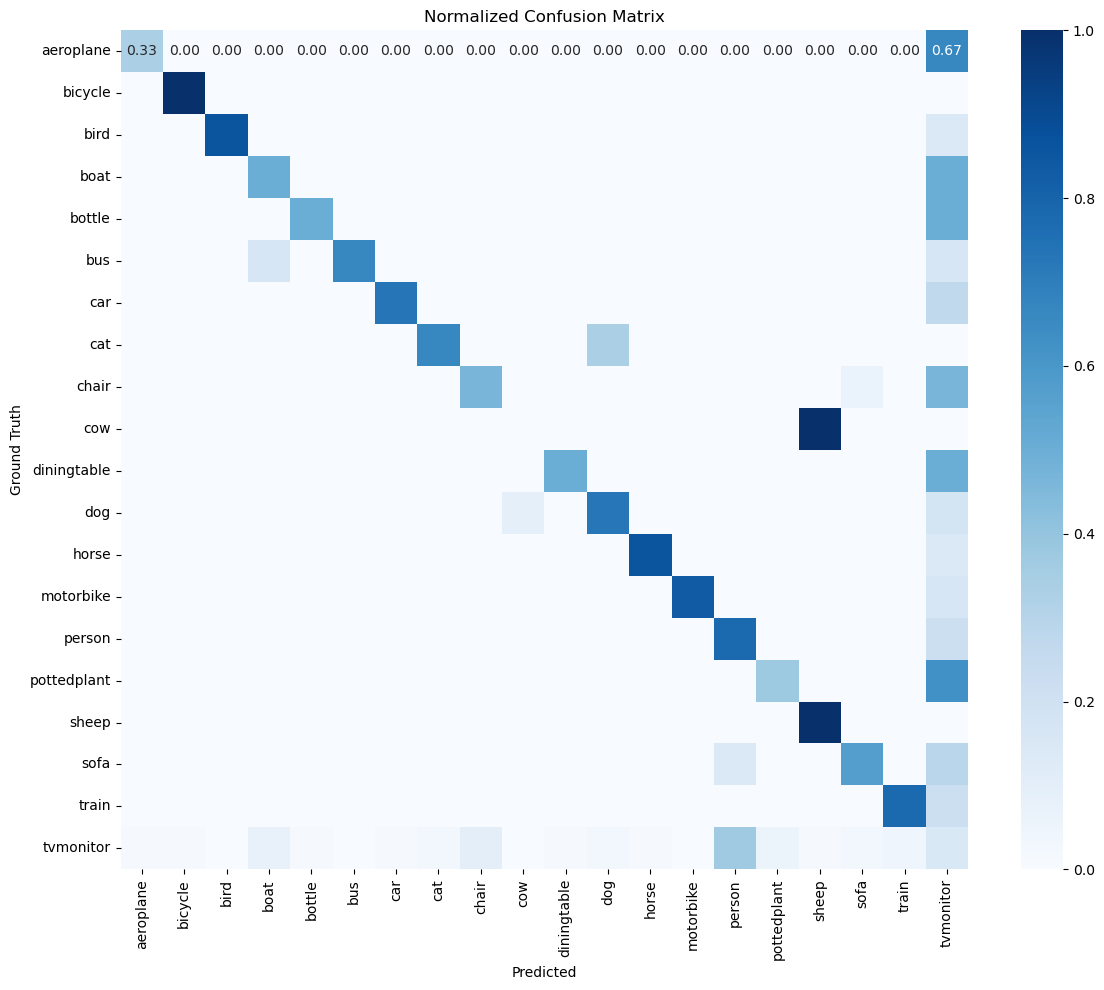


성능이 가장 낮은 클래스를 분석합니다...

가장 낮은 성능의 클래스: cow (클래스 ID: 9)
정밀도: 0.0000, 재현율: 0.0000, F1 점수: 0.0000
TP: 0, FP: 1, FN: 1


cow 클래스 이미지 검색:   0%|                                                                 | 0/5011 [00:00<?, ?it/s]


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000005.jpg: 256x320 5 chairs, 73.9ms
Speed: 0.8ms preprocess, 73.9ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000007.jpg: 224x320 1 car, 69.8ms
Speed: 0.6ms preprocess, 69.8ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 320)


cow 클래스 이미지 검색:   0%|                                                         | 2/5011 [00:00<06:43, 12.42it/s]


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000009.jpg: 256x320 1 horse, 4 persons, 75.3ms
Speed: 0.7ms preprocess, 75.3ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000012.jpg: 224x320 1 car, 74.0ms
Speed: 0.6ms preprocess, 74.0ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 320)


...

cow 클래스 이미지 검색:   4%|██▏                                                    | 200/5011 [00:17<07:12, 11.11it/s]


image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000407.jpg: 256x320 1 horse, 1 person, 93.3ms
Speed: 0.6ms preprocess, 93.3ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000408.jpg: 320x256 1 cow, 81.0ms
Speed: 1.1ms preprocess, 81.0ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 256)


cow 클래스 이미지 검색:   4%|██▏                                                    | 201/5011 [00:17<07:04, 11.33it/s]

cow 클래스에 해당하는 이미지 5개를 찾았습니다.

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000120.jpg: 256x320 1 cow, 79.7ms
Speed: 0.7ms preprocess, 79.7ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 320)



image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000211.jpg: 256x320 7 cows, 77.3ms
Speed: 0.7ms preprocess, 77.3ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000232.jpg: 256x320 1 aeroplane, 1 boat, 1 cow, 76.1ms
Speed: 0.6ms preprocess, 76.1ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000306.jpg: 128x320 2 cows, 1 horse, 2 sheeps, 47.4ms
Speed: 0.4ms preprocess, 47.4ms inference, 0.7ms postprocess per image at shape (1, 3, 128, 320)

image 1/1 C:\jupyter_project\Spring_cv\VOCdevkit\VOC2007\JPEGImages\000408.jpg: 320x256 1 cow, 72.2ms
Speed: 0.6ms preprocess, 72.2ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 256)


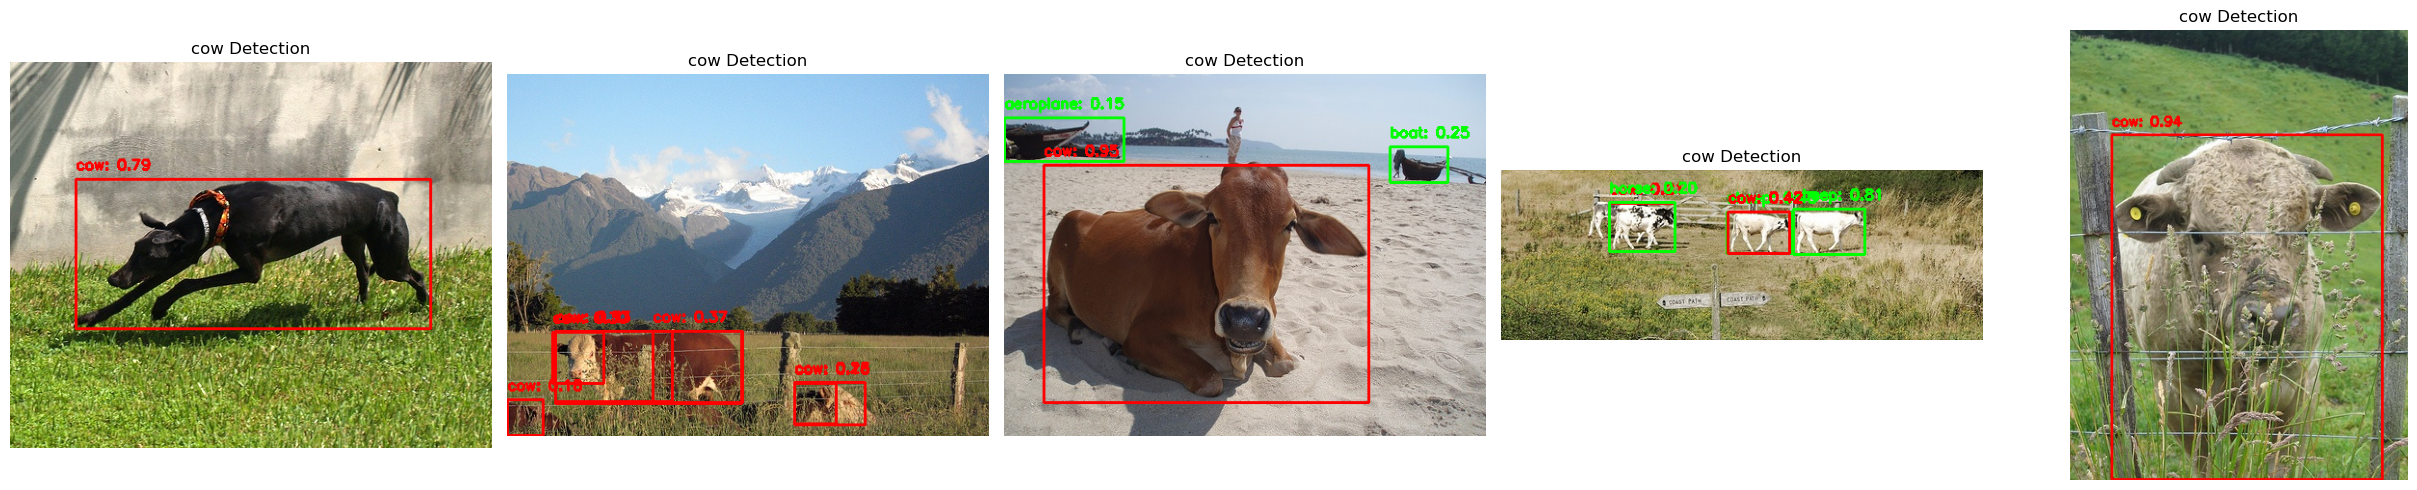


## 문제점 분석 ##
cow 클래스의 주요 문제점:
1. 데이터 불균형: 해당 클래스의 샘플 수가 매우 적습니다. 데이터셋에 더 많은 샘플을 추가하거나 데이터 증강 기법을 적용하세요.
2. 전반적으로 낮은 성능: 모델이 이 클래스를 인식하는 데 큰 어려움을 겪고 있습니다. 더 많은 데이터와 더 깊은 모델 아키텍처가 필요할 수 있습니다.

개선 제안:
1. 해당 클래스의 데이터를 더 수집하고 다양한 환경, 각도, 조명 조건에서의 샘플을 확보하세요.
2. 데이터 증강 기법을 적용하여 데이터셋의 다양성을 높이세요.
3. 클래스 간 혼동이 심한 경우, 특징 추출을 강화할 수 있는 backbone 네트워크나 앙상블 접근법을 고려하세요.
4. 테스트셋과 훈련셋 간의 분포 차이를 확인하고, 필요시 훈련 데이터를 조정하세요.

분석 결과는 results/cpu_inference_analysis 디렉토리에 저장되었습니다.


In [7]:
# 메인 실행 코드
if __name__ == "__main__":
    # 모델 경로 설정
    model_path = "/jupyter_project/Spring_cv/yolov5.pt"  # 저장된 모델 경로로 변경
    
    # 테스트 및 출력 디렉토리 설정
    test_dir = "/jupyter_project/Spring_cv/VOCdevkit/VOC2007/JPEGImages"  # 테스트 이미지 디렉토리로 변경
    annotation_dir = "/jupyter_project/Spring_cv/VOCdevkit/VOC2007/Annotations"  # 어노테이션 디렉토리로 변경
    output_dir = "results/cpu_inference_analysis"
    
    # 모델 로드
    model = load_model_on_cpu(model_path)
    
    # 배치 추론 및 결과 수집
    if os.path.exists(test_dir):
        print("배치 추론 및 성능 분석을 시작합니다...")
        all_results, all_gt, class_names = batch_inference(
            model, 
            test_dir, 
            output_dir, 
            conf=0.25, 
            max_images=100,
            ground_truth_file=annotation_dir
        )
        
        # 성능 지표 계산
        print("성능 지표를 계산 중입니다...")
        class_scores, confusion_mat, norm_confusion_mat = calculate_metrics(all_results, all_gt, class_names)
        
        # 클래스별 성능 출력
        print("\n클래스별 성능:")
        for cls_id, scores in class_scores.items():
            print(f"클래스 {cls_id} ({class_names[cls_id]}): Precision={scores['precision']:.4f}, Recall={scores['recall']:.4f}, F1={scores['f1']:.4f}")
        
        # 혼동 행렬 시각화
        print("\n혼동 행렬을 시각화합니다...")
        plot_confusion_matrix(confusion_mat, norm_confusion_mat, class_names, output_dir)
        
        # 가장 낮은 성능의 클래스 시각화 및 문제점 분석
        print("\n성능이 가장 낮은 클래스를 분석합니다...")
        worst_class_id, worst_class_name = visualize_worst_class(model, test_dir, output_dir, class_scores, class_names)
        
        print(f"\n분석 결과는 {output_dir} 디렉토리에 저장되었습니다.")
    else:
        print(f"테스트 디렉토리({test_dir})를 찾을 수 없습니다.")